#### Data Cleaning

In [1]:
!pip3 install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import pandas as pd
import numpy as np


In [3]:
# importing dataset
df = pd.read_excel('customer_data.xlsx')
df.head()

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05,Yes
1,C002,Female,38,40881.0,New York,West,15,157.640,4,In-store,2023-07-08,Yes
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30,No
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01,No
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23,No


In [4]:
# Identifying missing values
missing_value = df.isnull().sum()
print("Missing Values: ")
missing_value

Missing Values: 


CustomerID                  0
Gender                      0
Age                         0
Income                      5
City                        3
Region                      0
Frequency_of_Purchases      0
Average_Purchase_Amount     0
Customer_Lifespan_Months    0
Purchase_Channel            0
Date_of_Purchase            0
Churn_Status                0
dtype: int64

In [5]:
# Handling Missing values
from sklearn.impute import SimpleImputer

# Handling missing values of Income
income = SimpleImputer(strategy = 'median')
income.fit(df[['Income']])
df[['Income']] = income.transform(df[['Income']])

# Handling missing values of City
city = SimpleImputer(strategy = 'most_frequent')
city.fit(df[['City']])
df[['City']] = city.transform(df[['City']])



In [6]:
# Identifying missing values
missing_value = df.isnull().sum()
print("Missing Values: ")
missing_value

Missing Values: 


CustomerID                  0
Gender                      0
Age                         0
Income                      0
City                        0
Region                      0
Frequency_of_Purchases      0
Average_Purchase_Amount     0
Customer_Lifespan_Months    0
Purchase_Channel            0
Date_of_Purchase            0
Churn_Status                0
dtype: int64

In [7]:
# checking data types
df.dtypes

CustomerID                   object
Gender                       object
Age                           int64
Income                      float64
City                         object
Region                       object
Frequency_of_Purchases        int64
Average_Purchase_Amount     float64
Customer_Lifespan_Months     object
Purchase_Channel             object
Date_of_Purchase             object
Churn_Status                 object
dtype: object

In [8]:
# Checking invalid values
unique_values = df['Customer_Lifespan_Months'].unique()
print("Customer lifespan Months Values: ")
unique_values

Customer lifespan Months Values: 


array([3, 4, 1, 2, 5, 'XXXX'], dtype=object)

In [9]:
# Removing Invalid Values
df = df[df['Customer_Lifespan_Months'] != 'XXXX']

In [10]:
# Checking invalid values
unique_values = df['Customer_Lifespan_Months'].unique()
print("Customer lifespan Months Values: ")
unique_values

Customer lifespan Months Values: 


array([3, 4, 1, 2, 5], dtype=object)

In [11]:
# Converting Data Type to Integer
df['Customer_Lifespan_Months'] = df['Customer_Lifespan_Months'].astype(int)

In [12]:
# Converting Data Type to Datetime
df['Date_of_Purchase'] = pd.to_datetime(df['Date_of_Purchase'])

In [13]:
# checking data types
df.dtypes

CustomerID                          object
Gender                              object
Age                                  int64
Income                             float64
City                                object
Region                              object
Frequency_of_Purchases               int64
Average_Purchase_Amount            float64
Customer_Lifespan_Months             int64
Purchase_Channel                    object
Date_of_Purchase            datetime64[ns]
Churn_Status                        object
dtype: object

In [14]:
# Displaying dataset
df.head()

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05,Yes
1,C002,Female,38,40881.0,New York,West,15,157.640,4,In-store,2023-07-08,Yes
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30,No
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01,No
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23,No


In [15]:
# Checking Duplicate Data
duplicates = df.duplicated()
df[duplicates]

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
80,C021,Female,22,41743.0,Los Angeles,Northeast,4,54.599,1,Online,2023-06-08,No


In [16]:
# Removing Duplicate Data
df.drop_duplicates(inplace = True)

In [17]:
# Checking Duplicate Data
duplicates = df.duplicated()
df[duplicates]

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status


### Sorting and Filtering

In [18]:
# sorting 
sorted_data = df.sort_values(by='Income', ascending = False)
sorted_data

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
55,C056,Female,29,107662.0,Houston,Northeast,3,47.877,1,In-store,2022-02-11,No
22,C023,Female,41,105186.0,Los Angeles,Midwest,14,137.697,4,Online,2023-07-15,Yes
70,C071,Female,36,103264.0,Los Angeles,Northeast,11,117.394,3,Online,2023-12-22,Yes
32,C033,Female,31,98590.0,Houston,West,7,76.114,2,Online,2023-06-30,No
52,C053,Female,45,90860.0,Houston,Northeast,10,105.287,3,In-store,2023-12-29,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
14,C015,Male,44,32500.0,New York,Northeast,9,96.473,3,Online,2023-03-30,No
49,C050,Female,39,29104.0,Houston,Midwest,7,84.461,2,Online,2022-03-17,No
10,C011,Female,53,27958.0,Los Angeles,Midwest,10,98.449,3,In-store,2023-07-16,Yes
23,C024,Male,54,27660.0,New York,Midwest,12,125.763,3,Online,2023-07-11,Yes


In [19]:
# Filtering male data
male_data = df[df['Gender'] == 'Male']
male_data

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05,Yes
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30,No
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01,No
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23,No
5,C006,Male,52,76470.0,Chicago,Midwest,11,117.012,3,Online,2022-11-30,Yes
7,C008,Male,38,38401.0,Houston,West,6,70.730,2,Online,2022-05-24,No
8,C009,Male,44,73105.0,Los Angeles,Northeast,12,124.887,3,Online,2022-09-02,Yes
14,C015,Male,44,32500.0,New York,Northeast,9,96.473,3,Online,2023-03-30,No
15,C016,Male,37,59214.0,Houston,Midwest,10,108.902,3,Online,2022-01-02,Yes
17,C018,Male,39,86730.0,New York,Midwest,11,118.579,3,Online,2022-03-06,Yes


In [20]:
# Filtering Male Customers with more than 5  Purchase Frequency
male_fre_data = male_data[male_data['Frequency_of_Purchases']>5]
male_fre_data

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05,Yes
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01,No
5,C006,Male,52,76470.0,Chicago,Midwest,11,117.012,3,Online,2022-11-30,Yes
7,C008,Male,38,38401.0,Houston,West,6,70.730,2,Online,2022-05-24,No
8,C009,Male,44,73105.0,Los Angeles,Northeast,12,124.887,3,Online,2022-09-02,Yes
14,C015,Male,44,32500.0,New York,Northeast,9,96.473,3,Online,2023-03-30,No
15,C016,Male,37,59214.0,Houston,Midwest,10,108.902,3,Online,2022-01-02,Yes
17,C018,Male,39,86730.0,New York,Midwest,11,118.579,3,Online,2022-03-06,Yes
18,C019,Male,32,41111.0,Los Angeles,West,14,133.229,4,Online,2023-07-19,Yes
19,C020,Male,28,37050.0,Los Angeles,Midwest,6,71.789,2,Online,2022-04-08,No


In [21]:
# Filtering Churned Male Customers with more than 5 Purchase Frequency
churned_male_fre = male_fre_data.query('Churn_Status == "Yes"')
churned_male_fre

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05,Yes
5,C006,Male,52,76470.0,Chicago,Midwest,11,117.012,3,Online,2022-11-30,Yes
8,C009,Male,44,73105.0,Los Angeles,Northeast,12,124.887,3,Online,2022-09-02,Yes
15,C016,Male,37,59214.0,Houston,Midwest,10,108.902,3,Online,2022-01-02,Yes
17,C018,Male,39,86730.0,New York,Midwest,11,118.579,3,Online,2022-03-06,Yes
18,C019,Male,32,41111.0,Los Angeles,West,14,133.229,4,Online,2023-07-19,Yes
23,C024,Male,54,27660.0,New York,Midwest,12,125.763,3,Online,2023-07-11,Yes
24,C025,Male,27,45239.0,Los Angeles,West,12,127.888,3,In-store,2022-04-04,Yes
33,C034,Male,53,78203.0,Houston,Northeast,12,130.277,3,In-store,2023-06-05,Yes
38,C039,Male,43,51799.0,Houston,West,14,133.540,4,Online,2022-10-26,Yes


In [22]:
# Filtering Churned Male Customers from Specific Cities
churned_male_freq_city = churned_male_fre[churned_male_fre['City'].isin(['Chicago', 'Houston'])]
churned_male_freq_city

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05,Yes
5,C006,Male,52,76470.0,Chicago,Midwest,11,117.012,3,Online,2022-11-30,Yes
15,C016,Male,37,59214.0,Houston,Midwest,10,108.902,3,Online,2022-01-02,Yes
33,C034,Male,53,78203.0,Houston,Northeast,12,130.277,3,In-store,2023-06-05,Yes
38,C039,Male,43,51799.0,Houston,West,14,133.540,4,Online,2022-10-26,Yes
41,C042,Male,53,52616.0,Houston,Northeast,11,120.311,3,Online,2022-07-15,Yes
42,C043,Male,44,66344.0,Chicago,Midwest,12,130.562,3,In-store,2023-05-17,Yes
45,C046,Male,44,59154.0,Chicago,West,15,152.291,4,Online,2022-12-07,Yes
63,C064,Male,30,58033.0,Houston,West,10,107.919,3,In-store,2023-11-16,Yes
66,C067,Male,54,58033.0,Houston,West,12,128.255,3,Online,2022-03-24,Yes


In [23]:
# displaying dataset
df.head()

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05,Yes
1,C002,Female,38,40881.0,New York,West,15,157.640,4,In-store,2023-07-08,Yes
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30,No
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01,No
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23,No


In [24]:
# Displaying Selected Rows and Columns from Dataset
df.loc[0:4, 'CustomerID':'Region']

,CustomerID,Gender,Age,Income,City,Region
0,C001,Male,49,72504.0,Chicago,Northeast
1,C002,Female,38,40881.0,New York,West
2,C003,Male,17,63333.0,New York,Northeast
3,C004,Male,34,58030.0,Chicago,Midwest
4,C005,Male,30,78889.0,Houston,Midwest


In [25]:
# Displaying Dataset Using Index Positions
df.iloc[0:5, 0:6]

,CustomerID,Gender,Age,Income,City,Region
0,C001,Male,49,72504.0,Chicago,Northeast
1,C002,Female,38,40881.0,New York,West
2,C003,Male,17,63333.0,New York,Northeast
3,C004,Male,34,58030.0,Chicago,Midwest
4,C005,Male,30,78889.0,Houston,Midwest


In [26]:
# Filtering Customers Based on Lifespan Range
print("Customers with Lifespan Between 2 and 5 Months: ")
df[(df['Customer_Lifespan_Months'] >= 2) & (df['Customer_Lifespan_Months'] <=5 )]


Customers with Lifespan Between 2 and 5 Months: 


,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
0,C001,Male,49,72504.0,Chicago,Northeast,10,9.824100e+01,3,Online,2022-03-05,Yes
1,C002,Female,38,40881.0,New York,West,15,1.576400e+02,4,In-store,2023-07-08,Yes
5,C006,Male,52,76470.0,Chicago,Midwest,11,1.170120e+02,3,Online,2022-11-30,Yes
6,C007,Female,35,60349.0,Houston,Northeast,9,9.554400e+01,2,In-store,2023-07-20,No
7,C008,Male,38,38401.0,Houston,West,6,7.073000e+01,2,Online,2022-05-24,No
...,...,...,...,...,...,...,...,...,...,...,...,...
72,C073,Male,28,73631.0,Los Angeles,West,9,9.034400e+01,2,In-store,2022-11-20,No
75,C076,Male,44,59659.0,Houston,Midwest,14,1.345400e+02,4,Online,2023-12-25,Yes
77,C078,Male,30,76887.0,Houston,Midwest,7,8.081600e+01,2,Online,2022-11-14,No
78,C079,Female,42,56569.0,New York,West,11,1.342341e+07,3,In-store,2022-12-08,Yes


#### Joining Data

In [27]:
# Second Dataset
# importing dataset
df2 = pd.read_excel('performance_data.xlsx')
df2.head()

,CustomerID,Recency,Frequency_Score,Monetary_Score
0,C001,3,2,2
1,C002,3,3,3
2,C003,4,4,4
3,C004,2,2,2
4,C005,1,1,1


In [28]:
# Merging Two Datasets Using Inner Join
joined_data = pd.merge(df,df2, on='CustomerID', how='inner')
joined_data.head()

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,Recency,Frequency_Score,Monetary_Score
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05,Yes,3,2,2
1,C002,Female,38,40881.0,New York,West,15,157.640,4,In-store,2023-07-08,Yes,3,3,3
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30,No,4,4,4
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01,No,2,2,2
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23,No,1,1,1


In [29]:
# Checking the Shape of Dataset
joined_data.shape

(79, 15)

In [30]:
# Third Dataset
# Importing dataset
df3 = pd.read_excel('additional_data.xlsx')
df3.head()

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,CustomerID.1,Recency,Frequency_Score,Monetary_Score
0,C081,Male,37,50728,Chicago,West,11,75.757,2,In-store,2023-09-10,Yes,C081,2,2,1
1,C082,Female,48,69629,Los Angeles,Midwest,9,78.433,4,In-store,2023-07-15,No,C082,3,4,4
2,C083,Male,28,29184,Chicago,Northeast,7,82.794,3,Online,2023-08-25,Yes,C083,3,1,2
3,C084,Female,33,61265,Los Angeles,West,15,88.490,2,Online,2022-10-22,Yes,C084,4,1,3
4,C085,Female,30,63130,Houston,Midwest,13,108.749,3,Online,2023-04-01,Yes,C085,4,4,1


In [31]:
# Concatenating Multiple Datasets
final_data = (pd.concat([joined_data, df3])).reset_index(drop=True)
final_data.tail()

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,Recency,Frequency_Score,Monetary_Score,CustomerID.1
94,C096,Male,32,18600.0,Chicago,Northeast,12,123.003,4,Online,2022-02-03,Yes,4,2,3,C096
95,C097,Male,38,68525.0,Chicago,West,13,106.526,4,Online,2023-09-20,Yes,4,3,3,C097
96,C098,Female,24,73538.0,Houston,West,3,162.533,1,In-store,2023-11-04,Yes,2,1,1,C098
97,C099,Female,20,47251.0,Chicago,Midwest,5,145.404,2,In-store,2022-09-24,No,4,3,1,C099
98,C100,Male,39,52054.0,Chicago,Midwest,14,36.975,2,In-store,2023-05-03,No,1,4,4,C100


In [32]:
# Dropping Unnecessary Column from Dataset
final_data = final_data.drop('CustomerID.1', axis=1)
final_data.head()

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,Recency,Frequency_Score,Monetary_Score
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05 00:00:00,Yes,3,2,2
1,C002,Female,38,40881.0,New York,West,15,157.640,4,In-store,2023-07-08 00:00:00,Yes,3,3,3
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30 00:00:00,No,4,4,4
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01 00:00:00,No,2,2,2
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23 00:00:00,No,1,1,1


#### Data Analysis

In [33]:
# Analyzing Purchase Channel Distribution
freq_purchase_channel = final_data['Purchase_Channel'].value_counts()
freq_purchase_channel

Purchase_Channel
Online      65
In-store    34
Name: count, dtype: int64

In [34]:
# Calculating Percentage Distribution of Purchase Channels
perc_purchase_channel = freq_purchase_channel/len(final_data['Purchase_Channel'])*100
perc_purchase_channel

Purchase_Channel
Online      65.656566
In-store    34.343434
Name: count, dtype: float64

In [35]:
# Generating Descriptive Statistics
round(final_data.describe())

,Age,Income,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Recency,Frequency_Score,Monetary_Score
count,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0
mean,35.0,58115.0,9.0,135687.0,3.0,3.0,3.0,3.0
std,10.0,18618.0,3.0,1349094.0,1.0,1.0,1.0,1.0
min,17.0,15531.0,1.0,37.0,0.0,1.0,1.0,1.0
25%,28.0,45724.0,7.0,76.0,2.0,2.0,2.0,2.0
50%,35.0,58033.0,10.0,98.0,3.0,3.0,3.0,3.0
75%,42.0,71484.0,12.0,121.0,3.0,4.0,4.0,4.0
max,54.0,107662.0,16.0,13423412.0,5.0,4.0,4.0,4.0


In [36]:
# Removing Outliers from Dataset
final_data = final_data[final_data['Average_Purchase_Amount'] != 13423411.958]

In [37]:
round(final_data.describe())

,Age,Income,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Recency,Frequency_Score,Monetary_Score
count,98.0,98.0,98.0,98.0,98.0,98.0,98.0,98.0
mean,35.0,58131.0,9.0,98.0,3.0,3.0,3.0,3.0
std,10.0,18713.0,3.0,29.0,1.0,1.0,1.0,1.0
min,17.0,15531.0,1.0,37.0,0.0,1.0,1.0,1.0
25%,28.0,45482.0,7.0,76.0,2.0,2.0,2.0,2.0
50%,35.0,58033.0,10.0,97.0,3.0,3.0,3.0,3.0
75%,42.0,71994.0,12.0,120.0,3.0,4.0,4.0,4.0
max,54.0,107662.0,16.0,193.0,5.0,4.0,4.0,4.0


In [38]:
# Grouping Data by City and Finding Median Purchase Amount
city_purchase_amount = final_data.groupby('City')['Average_Purchase_Amount'].median()
city_purchase_amount

City
Chicago        102.1860
Houston         87.6615
Los Angeles    100.7250
New York        94.4690
Name: Average_Purchase_Amount, dtype: float64

In [39]:
# Creating a Pivot Table for Customer Churn Analysis
pivot_table = final_data.pivot_table(index = 'Churn_Status', 
                                     values = ['Recency', 'Frequency_Score', 'Monetary_Score'], 
                                     aggfunc = {'Recency':'mean', 'Frequency_Score':'mean', 'Monetary_Score':'mean', 'Churn_Status':'count'})

In [40]:
# Changing Column Names for Better Readability
pivot_table = pivot_table.rename(columns = {'Churn_Status':'Freq_churn', 
                                            'Recency':'Mean_recency', 
                                            'Frequency_Score':'Mean_FS', 'Monetary_Score':'Mean_MS'})

In [41]:
# Displaying the Pivot Table
pivot_table

,Freq_churn,Mean_FS,Mean_MS,Mean_recency
Churn_Status,,,,
No,43,2.744186,2.558140,2.720930
Yes,55,2.509091,2.509091,2.618182


In [42]:
# Creating a Cross Tabulation Between City and Churn Status
cross_tab = pd.crosstab(final_data['City'], final_data['Churn_Status'])
cross_tab

Churn_Status,No,Yes
City,,
Chicago,8,17
Houston,16,16
Los Angeles,10,14
New York,9,8


In [43]:
# Selecting Numerical Columns from Dataset
num_variables = final_data.select_dtypes(include = ['number']).columns

In [44]:
# Displaying Numerical Variables
num_variables

Index(['Age', 'Income', 'Frequency_of_Purchases', 'Average_Purchase_Amount',
       'Customer_Lifespan_Months', 'Recency', 'Frequency_Score',
       'Monetary_Score'],
      dtype='object')

In [45]:
# Calculating Correlation Between Numerical Variables
correl = round(final_data[num_variables].corr(), 3)
correl

,Age,Income,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Recency,Frequency_Score,Monetary_Score
Age,1.000,0.110,0.301,0.170,0.334,-0.048,-0.006,0.065
Income,0.110,1.000,-0.022,0.023,0.068,0.178,0.163,0.162
Frequency_of_Purchases,0.301,-0.022,1.000,0.704,0.762,-0.063,-0.065,-0.066
Average_Purchase_Amount,0.170,0.023,0.704,1.000,0.690,-0.029,-0.145,-0.191
Customer_Lifespan_Months,0.334,0.068,0.762,0.690,1.000,-0.073,-0.013,-0.001
Recency,-0.048,0.178,-0.063,-0.029,-0.073,1.000,0.761,0.743
Frequency_Score,-0.006,0.163,-0.065,-0.145,-0.013,0.761,1.000,0.819
Monetary_Score,0.065,0.162,-0.066,-0.191,-0.001,0.743,0.819,1.000


#### Data Visualization

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

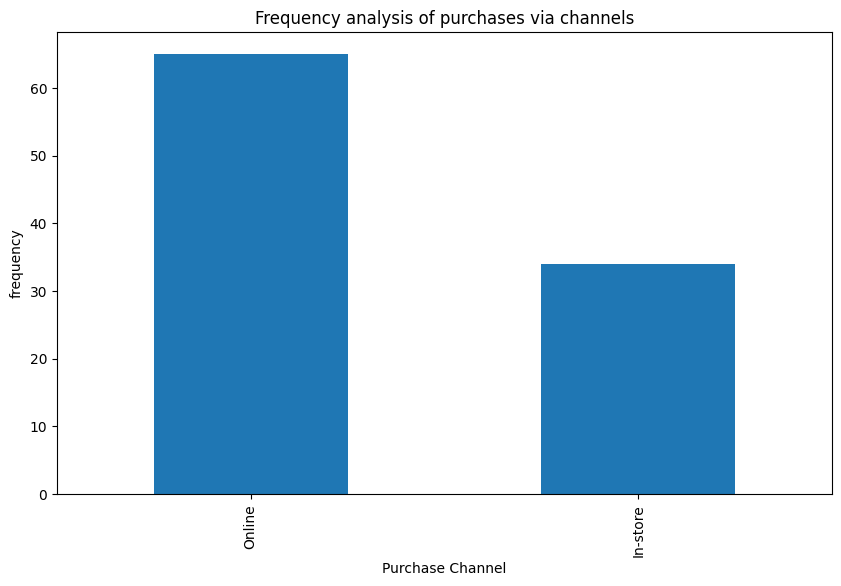

In [47]:
# Bar Chart for Purchase Channel Frequency Analysis
plt.figure(figsize = (10,6))
freq_purchase_channel.plot(kind = 'bar')
plt.title("Frequency analysis of purchases via channels")
plt.xlabel('Purchase Channel')
plt.ylabel('frequency')
plt.show()

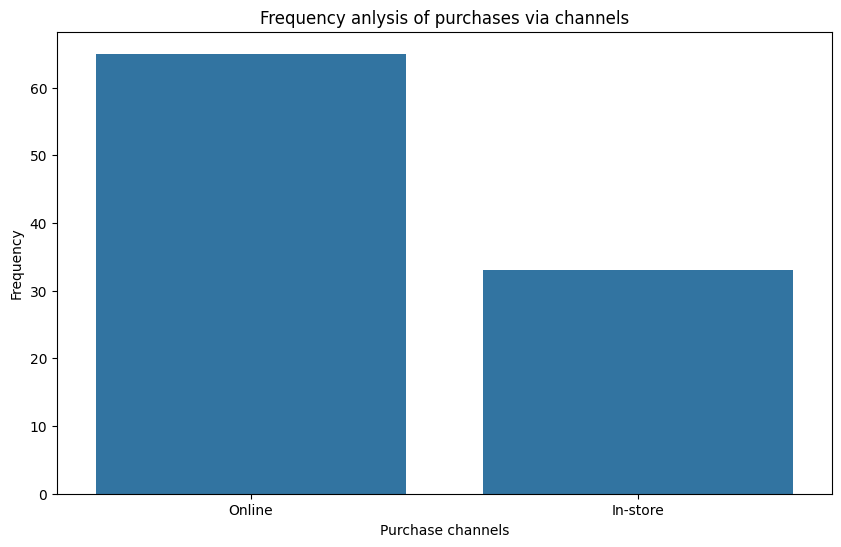

In [48]:
# Count Plot for Purchase Channel Frequency Analysis
plt.figure(figsize = (10, 6))
sns.countplot(x = 'Purchase_Channel', data = final_data)
plt.title('Frequency anlysis of purchases via channels')
plt.xlabel('Purchase channels')
plt.ylabel('Frequency')
plt.show()

<Figure size 1000x600 with 0 Axes>

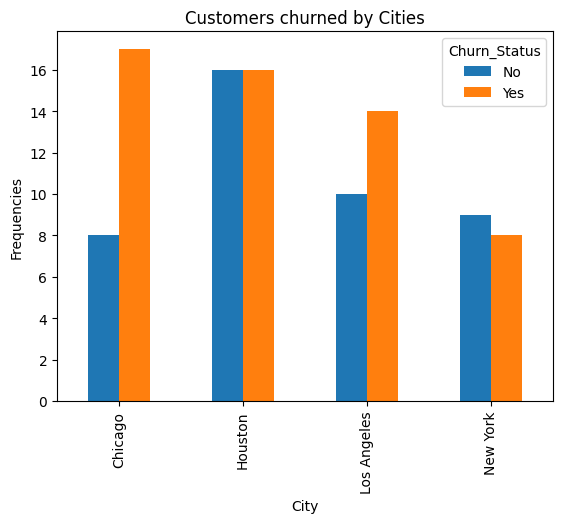

In [49]:
# Bar Chart of Customer Churn by City
plt.figure(figsize = (10, 6))
cross_tab.plot(kind = 'bar', stacked = False)
plt.title('Customers churned by Cities')
plt.xlabel('City')
plt.ylabel('Frequencies')
plt.show()

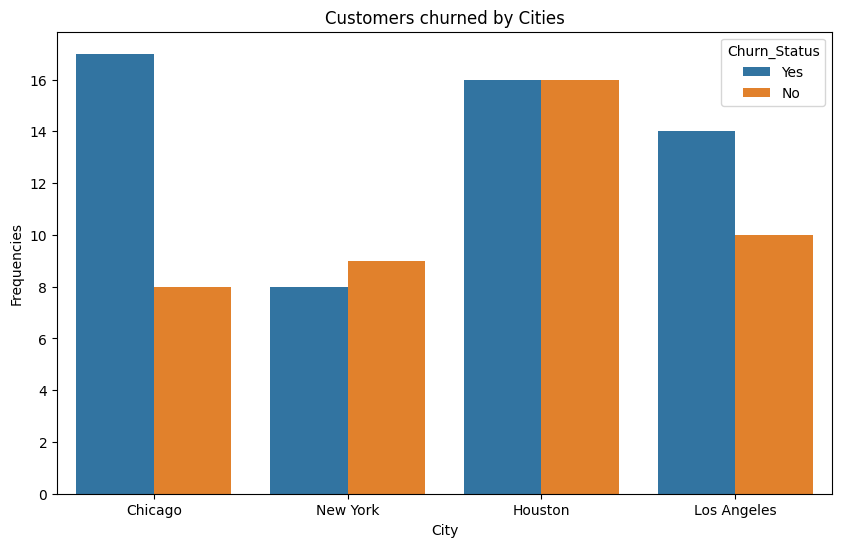

In [50]:
# count plot of Customer Churn by City
plt.figure(figsize = (10, 6))
sns.countplot(x = 'City', hue = 'Churn_Status', data = final_data)
plt.title('Customers churned by Cities')
plt.xlabel('City')
plt.ylabel('Frequencies')
plt.show()

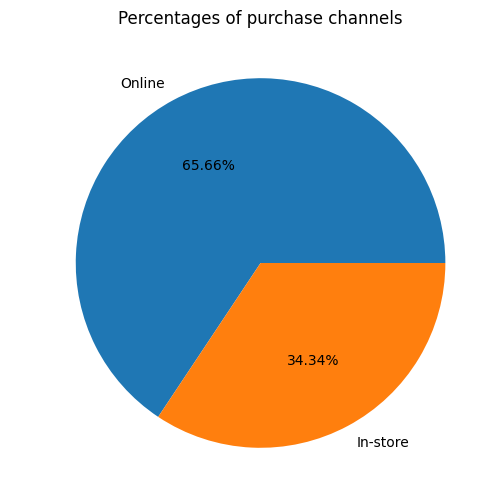

In [51]:
# Pie Chart of Purchase Channel Percentages
plt.figure(figsize = (10, 6))
perc_purchase_channel.plot(kind = 'pie', autopct = '%1.2f%%')
plt.title('Percentages of purchase channels')
plt.ylabel(' ')
plt.show()

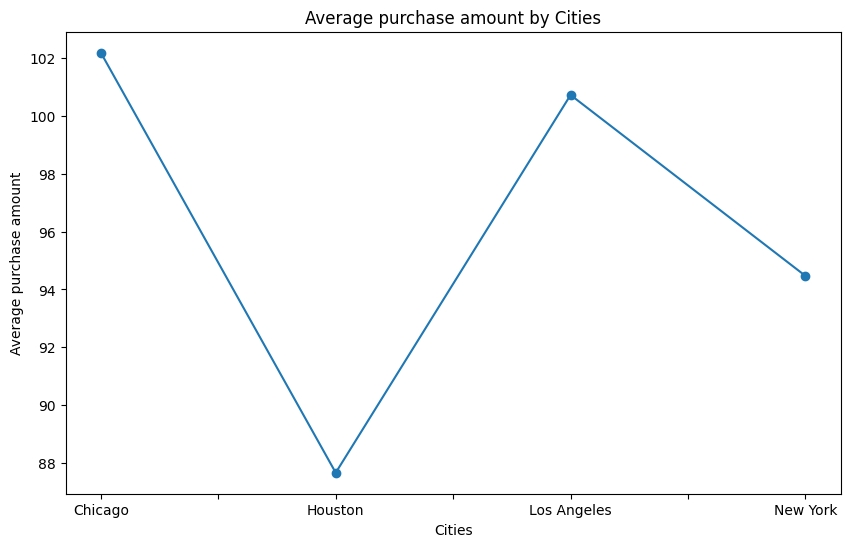

In [52]:
# Line Chart of Average Purchase Amount by City
plt.figure(figsize = (10, 6))
city_purchase_amount.plot(kind = 'line', marker = 'o')
plt.title('Average purchase amount by Cities')
plt.xlabel('Cities')
plt.ylabel('Average purchase amount')
plt.show()

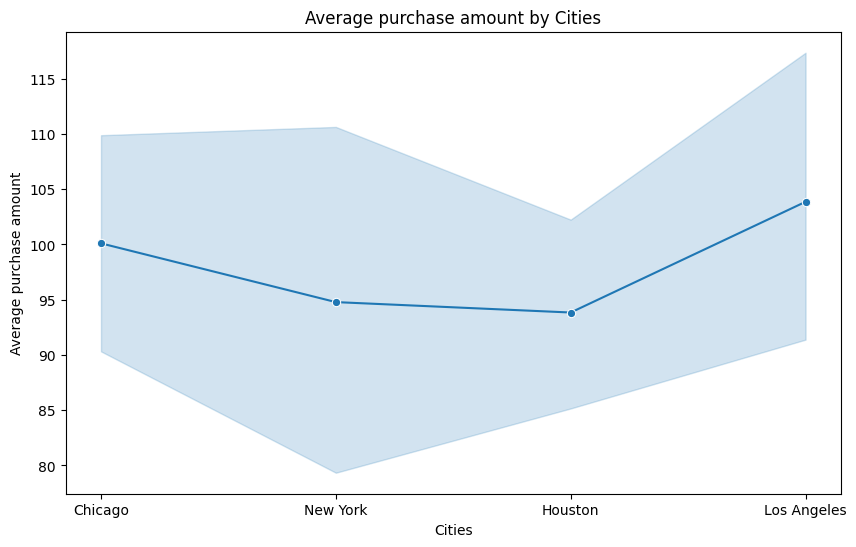

In [53]:
# Seaborn Line Plot of Average Purchase Amount by City
plt.figure(figsize = (10, 6))
sns.lineplot(x = 'City', y = 'Average_Purchase_Amount', data = final_data, marker = 'o')
plt.title('Average purchase amount by Cities')
plt.xlabel('Cities')
plt.ylabel('Average purchase amount')
plt.show()

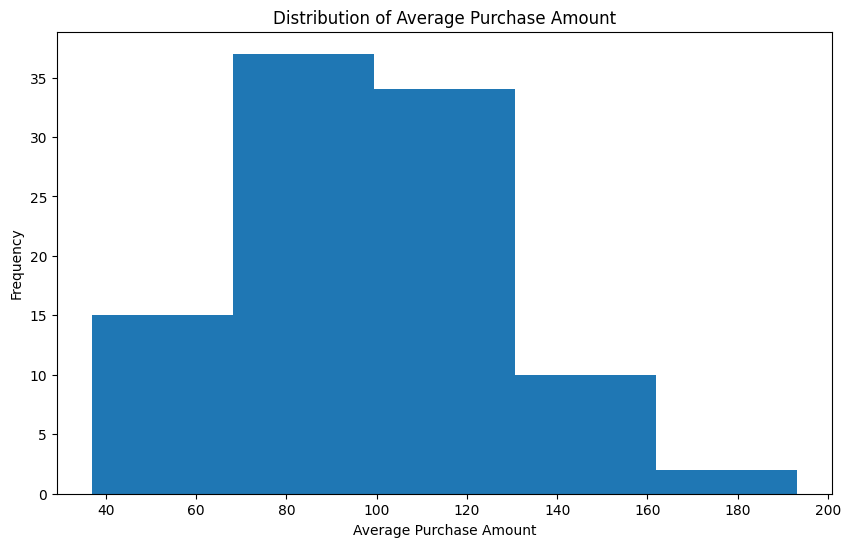

In [54]:
# Histogram of Average Purchase Amount
plt.figure(figsize = (10, 6))
final_data['Average_Purchase_Amount'].plot(kind = 'hist', bins = 5)
plt.title('Distribution of Average Purchase Amount')
plt.xlabel('Average Purchase Amount')
plt.ylabel('Frequency')
plt.show()

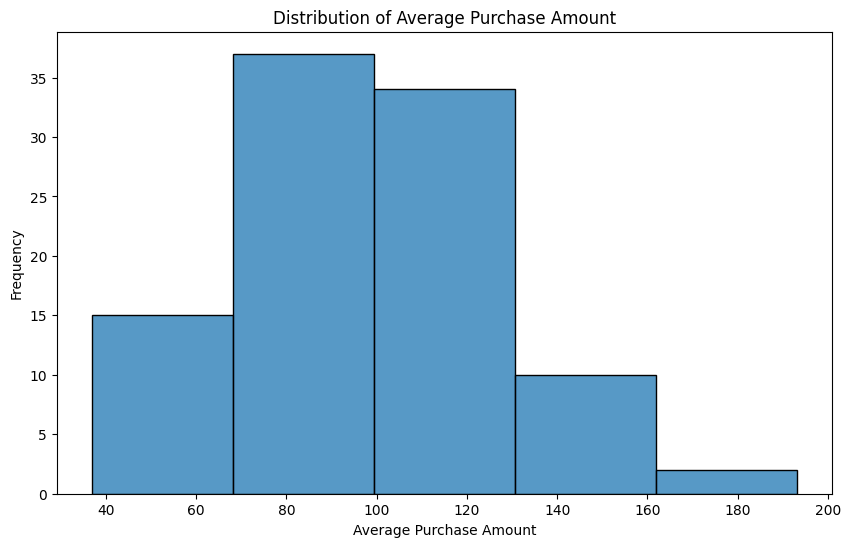

In [55]:
# Seaborn Histogram of Average Purchase Amount
plt.figure(figsize = (10, 6))
sns.histplot(final_data['Average_Purchase_Amount'], bins = 5)
plt.title('Distribution of Average Purchase Amount')
plt.xlabel('Average Purchase Amount')
plt.ylabel('Frequency')
plt.show()

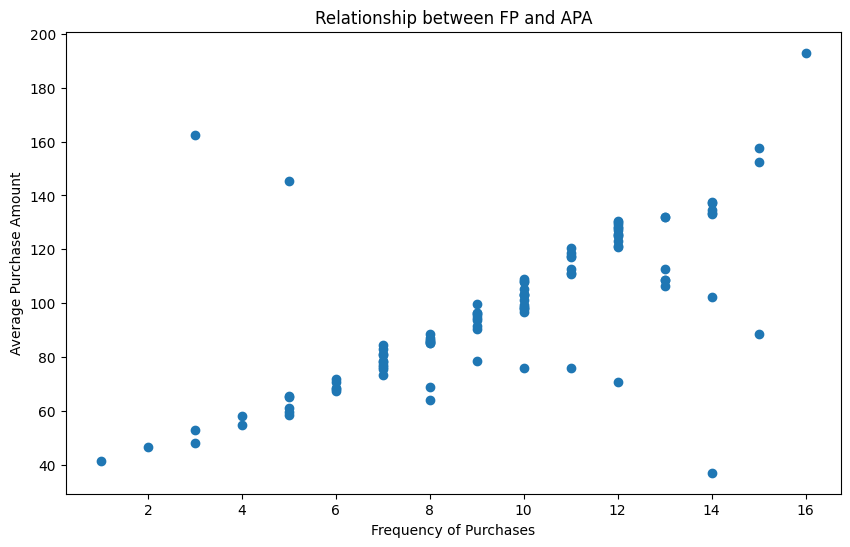

In [56]:
# Scatter Plot of Frequency of Purchases vs Average Purchase Amount
plt.figure(figsize = (10, 6))
plt.scatter(final_data['Frequency_of_Purchases'], final_data['Average_Purchase_Amount'])
plt.title('Relationship between FP and APA')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Average Purchase Amount')
plt.show()

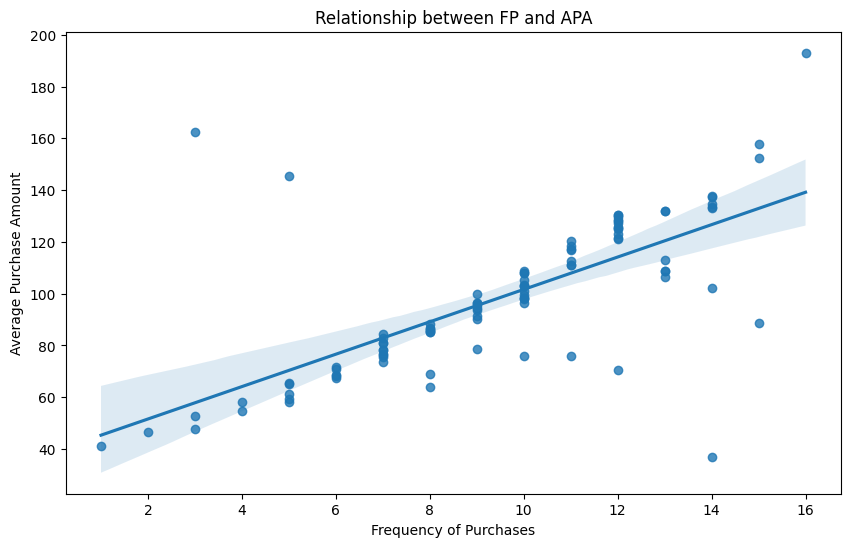

In [57]:
# Regression Plot of Frequency of Purchases vs Average Purchase Amount
plt.figure(figsize = (10, 6))
sns.regplot(x = 'Frequency_of_Purchases', y = 'Average_Purchase_Amount', data = final_data)
plt.title('Relationship between FP and APA')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Average Purchase Amount')
plt.show()

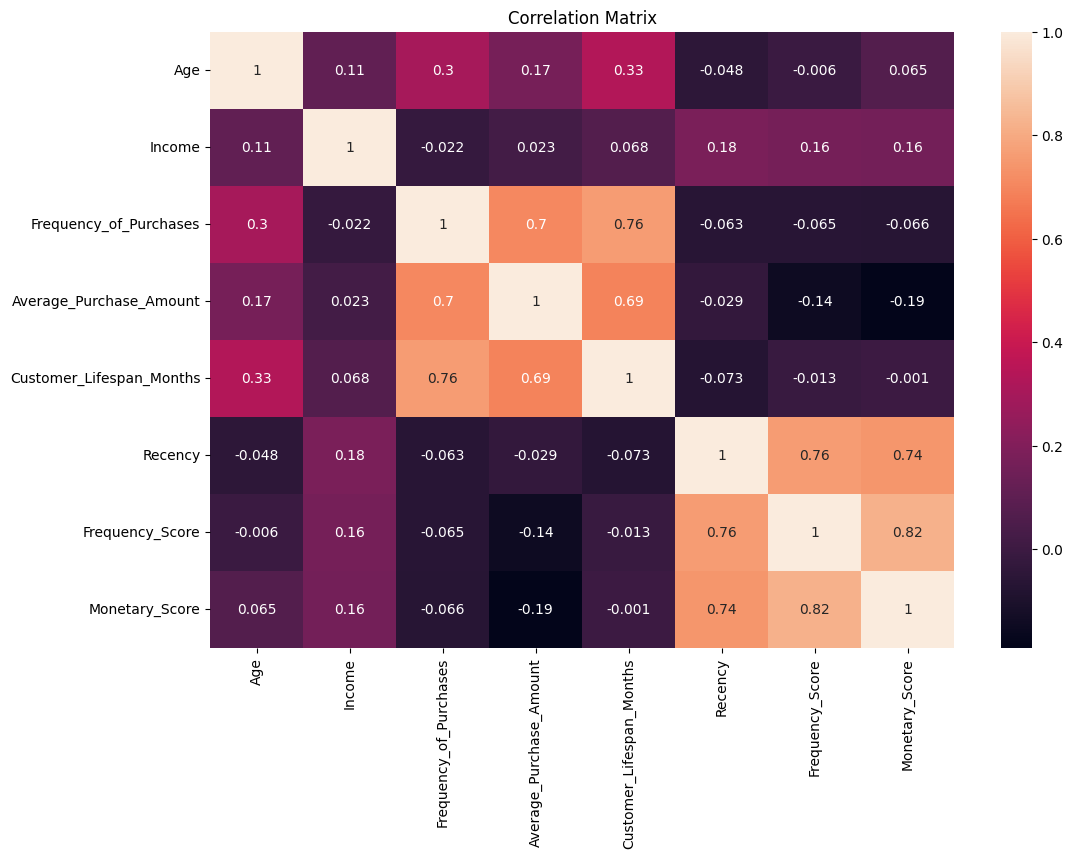

In [58]:
# Heatmap of Correlation Matrix
plt.figure(figsize = (12, 8))
sns.heatmap(correl, annot = True)
plt.title('Correlation Matrix')
plt.show()

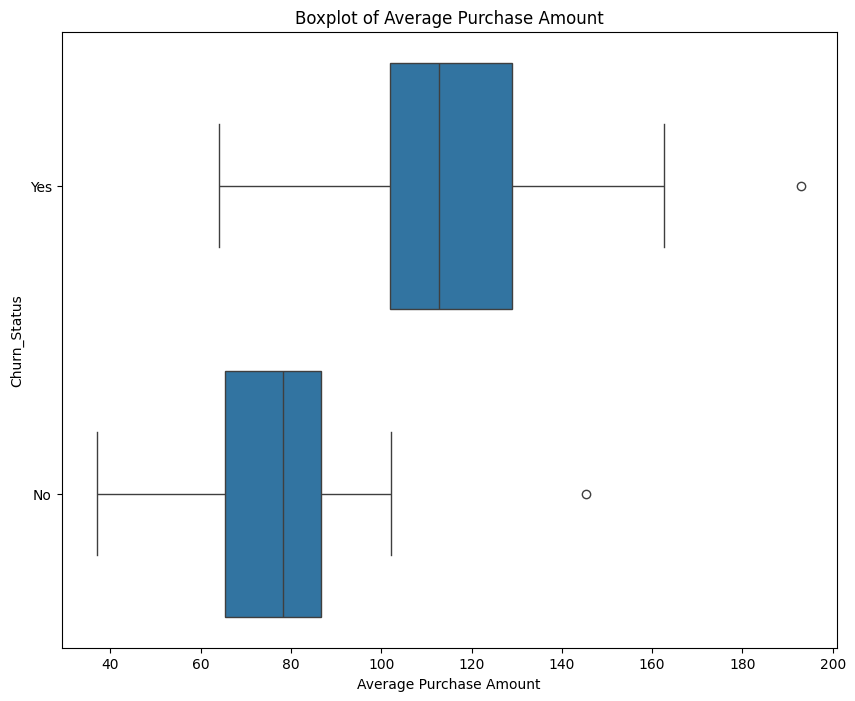

In [59]:
# Boxplot of Average Purchase Amount by Churn Status
plt.figure(figsize = (10, 8))
sns.boxplot(x = 'Average_Purchase_Amount', y = 'Churn_Status', data = final_data)
plt.title('Boxplot of Average Purchase Amount')
plt.xlabel('Average Purchase Amount')
plt.show()

#### Data Transfornation

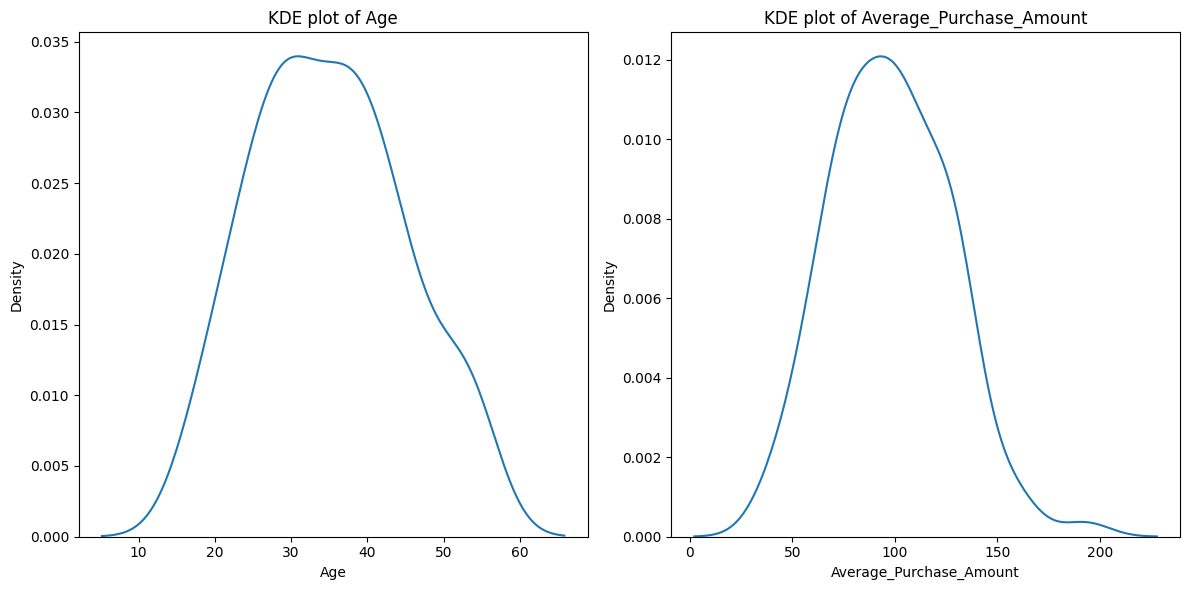

In [60]:
# KDE Plots for Numerical Variables
numeric_columns = ['Age', 'Average_Purchase_Amount']

fig, axes = plt.subplots(1, 2, figsize = (12, 6))

for index, column in enumerate(numeric_columns):
    sns.kdeplot(final_data[column], ax = axes[index])
    axes[index].set_title(f'KDE plot of {column}')
    
plt.tight_layout()
plt.show()

In [61]:
# Testing Numerical Variables for Normal Distribution

#Importing Shapiro Test
from scipy.stats import shapiro

shapiro_results = {}

for column in numeric_columns:
    stat, p_value = shapiro(final_data[column])
    shapiro_results[column] = round(p_value, 3)
    
shapiro_results

{'Age': np.float64(0.037), 'Average_Purchase_Amount': np.float64(0.487)}

Axes(0.125,0.11;0.775x0.77)
P value:  0.09854088997154391


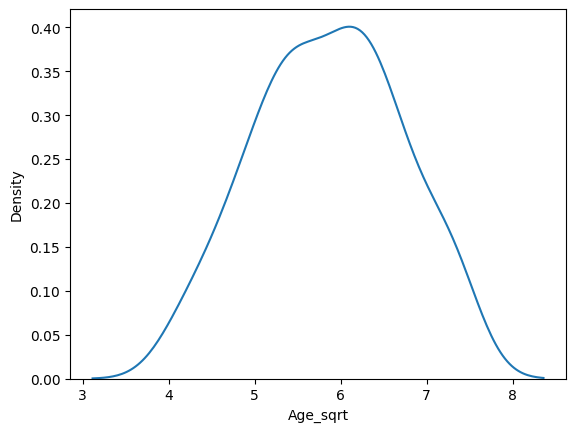

In [62]:
# Applying Square Root Transformation and Testing Normality
def sqrt_transformation(data, column_name):
    data[f'{column_name}_sqrt'] = np.sqrt(data[column_name])
    stat, p_value = shapiro(data[f'{column_name}_sqrt'])
    kdeplot = sns.kdeplot(data[f'{column_name}_sqrt'])
    
    print(kdeplot)
    print('P value: ', p_value)

sqrt_transformation(final_data, 'Age')

In [63]:
# Displaying First 5 Rows of Final Dataset
final_data.head()

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,Recency,Frequency_Score,Monetary_Score,Age_sqrt
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05 00:00:00,Yes,3,2,2,7.000000
1,C002,Female,38,40881.0,New York,West,15,157.640,4,In-store,2023-07-08 00:00:00,Yes,3,3,3,6.164414
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30 00:00:00,No,4,4,4,4.123106
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01 00:00:00,No,2,2,2,5.830952
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23 00:00:00,No,1,1,1,5.477226


In [64]:
# Applying Log Transformation and Testing Normality
def log_transformation(data, column_name):
    data[f'{column_name}_log'] = np.log(data[column_name])
    stat, p_value = shapiro(data[f'{column_name}_log'])
    kdeplot = sns.kdeplot(data[f'{column_name}_log'])
    
    print(kdeplot)
    print('P_value: ', p_value)

Axes(0.125,0.11;0.775x0.77)
P_value:  0.03301636122262333


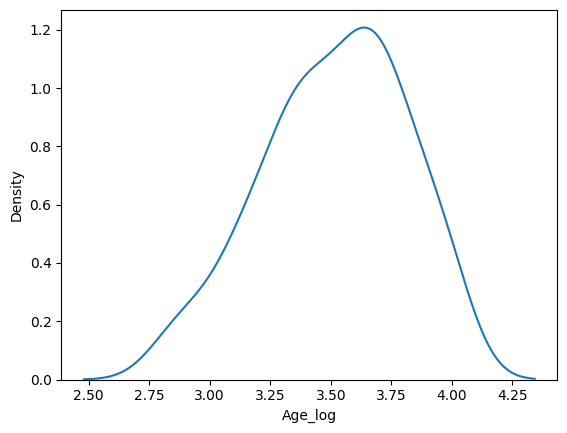

In [65]:
# Applying Log Transformation to Age Column
log_transformation(final_data, 'Age')

In [66]:
# Removing Transformed Column from Dataset
final_data = final_data.drop('Age_log', axis = 1)
final_data.head()

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,Recency,Frequency_Score,Monetary_Score,Age_sqrt
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05 00:00:00,Yes,3,2,2,7.000000
1,C002,Female,38,40881.0,New York,West,15,157.640,4,In-store,2023-07-08 00:00:00,Yes,3,3,3,6.164414
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30 00:00:00,No,4,4,4,4.123106
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01 00:00:00,No,2,2,2,5.830952
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23 00:00:00,No,1,1,1,5.477226


In [67]:
# Applying Box-Cox Transformation and Testing Normality
# Importing Box-Cox Function
from scipy.stats import boxcox

def boxcox_transformation(data, column_name):
    transformed_data, _ = boxcox(data[column_name])
    data[f'{column_name}_boxcox'] = transformed_data
    stat, p_value = shapiro(data[f'{column_name}_boxcox'])
    kdeplot = sns.kdeplot(data[f'{column_name}_boxcox'])
    
    print(kdeplot)
    print('P value: ', p_value)

Axes(0.125,0.11;0.775x0.77)
P value:  0.09806346287562501


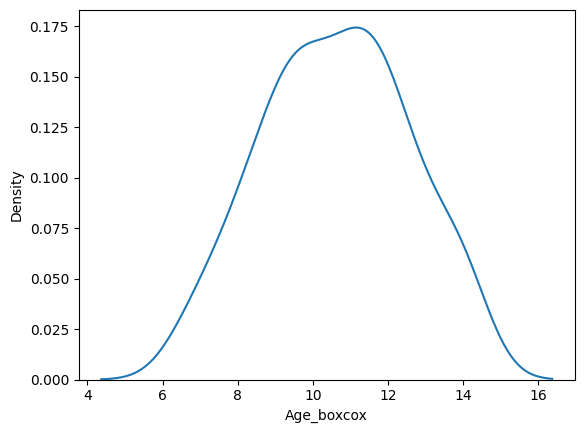

In [68]:
boxcox_transformation(final_data, 'Age')


In [69]:
# Applying Yeo-Johnson Transformation and Testing Normality

# Import Yeo-Johnson Function
from scipy.stats import yeojohnson

def yeojohnson_transformation(data, column_name):
    transformed_data, _ = yeojohnson(data[column_name])
    data[f'{column_name}_yeojohnson'] = transformed_data
    stat, p_value = shapiro(data[f'{column_name}_yeojohnson'])
    kdeplot = sns.kdeplot(data[f'{column_name}_yeojohnson'])
    
    print(kdeplot)
    print('P value: ', p_value)

Axes(0.125,0.11;0.775x0.77)
P value:  0.09733558189403681


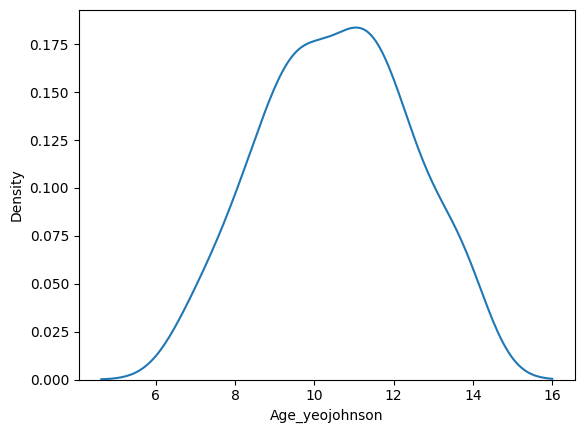

In [70]:
yeojohnson_transformation(final_data, 'Age')

In [71]:
# Removing Unnecessary Columns from Dataset
preprocessed_data = final_data.drop(['Age', 'Age_boxcox', 'Age_yeojohnson'], axis = 1)
preprocessed_data.head()

,CustomerID,Gender,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,Recency,Frequency_Score,Monetary_Score,Age_sqrt
0,C001,Male,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05 00:00:00,Yes,3,2,2,7.000000
1,C002,Female,40881.0,New York,West,15,157.640,4,In-store,2023-07-08 00:00:00,Yes,3,3,3,6.164414
2,C003,Male,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30 00:00:00,No,4,4,4,4.123106
3,C004,Male,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01 00:00:00,No,2,2,2,5.830952
4,C005,Male,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23 00:00:00,No,1,1,1,5.477226


#### Stastical Analysis

In [ ]:
from scipy import stats

# Hypothesis Testing Using One-Sample T-Test

hypothesized_mean = 68
t_stat, p_value = stats.ttest_1samp(preprocessed_data['Average_Purchase_Amount'], hypothesized_mean)
print("P value: ", p_value)

if p_value < 0.05:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

P value:  3.7658827996211955e-17
Reject the null hypothesis


In [ ]:
# Comparing Purchase Amounts of Churned and Existing Customers
churned_customers = preprocessed_data.query('Churn_Status == "Yes"')['Average_Purchase_Amount']
existing_customers = preprocessed_data.query('Churn_Status == "No"')['Average_Purchase_Amount']

t_stat, p_value = stats.ttest_ind(churned_customers, existing_customers)
print("P value:", p_value)

if p_value < 0.05:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

P value: 1.077550720319439e-13
Reject the null hypothesis


In [ ]:
# Calculating Mean Purchase Amount of Churned Customers
churned_customers.mean()

np.float64(114.96134545454547)

In [ ]:
# Calculating Mean Purchase Amount of Existing customers
existing_customers.mean()

np.float64(76.42560465116279)

In [ ]:
# Testing Normality of Frequency of Purchases
stat, p_value = shapiro(preprocessed_data['Frequency_of_Purchases'])
print(p_value)

0.11246168308147717


In [ ]:
# One-Way ANOVA Test for Frequency of Purchases Across Cities
chicago_cust = preprocessed_data.query('City == "Chicago"')['Frequency_of_Purchases']
newyork_cust = preprocessed_data.query('City == "New York"')['Frequency_of_Purchases']
houston_cust = preprocessed_data.query('City == "Houston"')['Frequency_of_Purchases']
losangeles_cust = preprocessed_data.query('City == "Los Angeles"')['Frequency_of_Purchases']

Test_stat, p_value = stats.f_oneway(chicago_cust, newyork_cust, houston_cust, losangeles_cust)
print("P value: ", p_value)

if p_value < 0.05:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

P value:  0.09375619087068894
Fail to reject the null hypothesis


In [ ]:
# Levene’s Test for Equality of Variances

from scipy.stats import levene

stats, p_value = levene(chicago_cust, newyork_cust, houston_cust, losangeles_cust)
print('P value: ', p_value)

P value:  0.5007918375821501


In [ ]:
# Chi-Square Test of Independence

from scipy.stats import chi2_contingency

cross_tab = pd.crosstab(preprocessed_data['Purchase_Channel'], preprocessed_data['Region'])

chi2, p_value, dof, expected = chi2_contingency(cross_tab)
print(" P value :", p_value)

if p_value < 0.05:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

 P value : 0.628361041713461
Fail to reject the null hypothesis


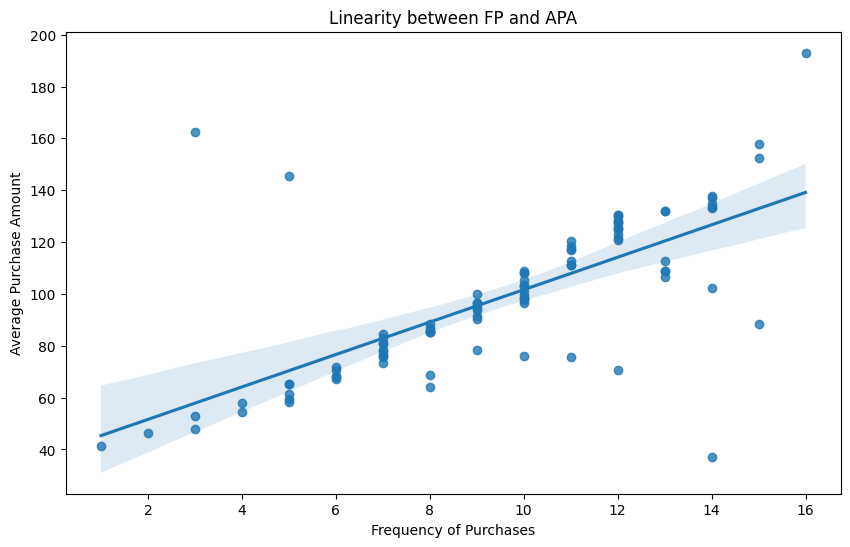

In [ ]:
# Visualizing Linear Relationship Between FP and APA
plt.figure(figsize = (10, 6))
sns.regplot(x = 'Frequency_of_Purchases', y = 'Average_Purchase_Amount', data = preprocessed_data)
plt.title('Linearity between FP and APA')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Average Purchase Amount')
plt.show()

In [ ]:
# Pearson Correlation Test Between Purchase Frequency and Purchase Amount
from scipy.stats import pearsonr

purchase_frequency = preprocessed_data['Frequency_of_Purchases']
purchase_amount = preprocessed_data['Average_Purchase_Amount']

corr, p_value = pearsonr(purchase_frequency, purchase_amount)
print("Correlation coefficient: ", corr)
print("P value: ", p_value)

if p_value < 0.05:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

Correlation coefficient:  0.7039911501130026
P value:  6.176786543554941e-16
Reject the null hypothesis


In [85]:
!pip3 install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 16.7 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [ ]:
# Simple Linear Regression Analysis Using OLS
import statsmodels.api as sm

x = preprocessed_data['Frequency_of_Purchases']
y = preprocessed_data['Average_Purchase_Amount']

x_constant = sm.add_constant(x)
model = sm.OLS(y, x_constant).fit()

print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     Average_Purchase_Amount   R-squared:                       0.496
Model:                                 OLS   Adj. R-squared:                  0.490
Method:                      Least Squares   F-statistic:                     94.33
Date:                     Tue, 19 May 2026   Prob (F-statistic):           6.18e-16
Time:                             12:00:59   Log-Likelihood:                -435.04
No. Observations:                       98   AIC:                             874.1
Df Residuals:                           96   BIC:                             879.3
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [ ]:
# Predicting Average Purchase Amount Using Linear Regression Equation
predicted_APA = 39.0765 + (6.2551 * 70)
predicted_APA

476.9335